<a href="https://colab.research.google.com/github/noahcoulson/mis433/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
accounts = pd.read_csv('/content/drive/My Drive/accounts.csv', header=0)

churn_test = pd.read_csv('/content/drive/My Drive/churn_test.csv', header=0)

churn_train = pd.read_csv('/content/drive/My Drive/churn_train.csv', header=0)

demographics = pd.read_csv('/content/drive/My Drive/demographics.csv', header=0)

services = pd.read_csv('/content/drive/My Drive/services.csv', header=0)

sample_submission = pd.read_csv('/content/drive/My Drive/sample_submission.csv', header=0)

In [25]:
#
accounts.info()

print(' ')
print(str(accounts.shape[0]) + ' Rows')

print(str(accounts.shape[1]) + ' Columns')

accounts.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5298 entries, 0 to 5297
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerNo         5298 non-null   int64  
 1   BaseCharges        5298 non-null   float64
 2   DOC                5298 non-null   object 
 3   TotalCharges       5288 non-null   float64
 4   DOE                5298 non-null   object 
 5   ElectronicBilling  5298 non-null   object 
 6   ContractType       5293 non-null   object 
 7   PaymentMethod      5298 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 331.3+ KB
 
5298 Rows
8 Columns


,CustomerNo,BaseCharges,DOC,TotalCharges,DOE,ElectronicBilling,ContractType,PaymentMethod
0,1201,478.50,5-1-2012,5920.00,10-Jan-11,No,One year,Electronic check
1,1202,103.25,5-1-2012,103.25,6-Dec-11,No,Month-to-month,Electronic check
2,1203,399.75,5-1-2012,5217.00,10-Jan-11,Yes,Month-to-month,Bank transfer (automatic)
3,1204,324.75,5-1-2012,22757.50,6-Apr-06,No,One year,Bank transfer (automatic)
4,1205,372.50,5-1-2012,372.50,6-Dec-11,Yes,Month-to-month,Electronic check


### Exploratory Data Analysis (EDA) for 'accounts' DataFrame

In [30]:
# Check for missing values
print("Missing values in 'accounts' DataFrame:")
display(accounts.isnull().sum())

Missing values in 'accounts' DataFrame:


,0
CustomerNo,0
BaseCharges,0
DOC,0
TotalCharges,10
DOE,0
ElectronicBilling,0
ContractType,5
PaymentMethod,0


In [26]:
churn_test.info()

print(' ')
print(str(churn_test.shape[0]) + ' Rows')

print(str(churn_test.shape[1]) + ' Columns')

churn_test.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1060 entries, 0 to 1059
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   CustomerNo  1060 non-null   int64
dtypes: int64(1)
memory usage: 8.4 KB
 
1060 Rows
1 Columns


,CustomerNo
0,1203
1,1204
2,1208
3,1220
4,1221


In [27]:
churn_train.info()

print(' ')
print(str(churn_train.shape[0]) + ' Rows')

print(str(churn_train.shape[1]) + ' Columns')

churn_train.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   CustomerNo  4238 non-null   int64
 1   Churn       4238 non-null   int64
dtypes: int64(2)
memory usage: 66.3 KB
 
4238 Rows
2 Columns


,CustomerNo,Churn
0,1201,0
1,1202,0
2,1205,1
3,1206,0
4,1207,0


In [28]:
demographics.info()

print(' ')
print(str(demographics.shape[0]) + ' Rows')

print(str(demographics.shape[1]) + ' Columns')

demographics.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5298 entries, 0 to 5297
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerNo     5298 non-null   int64 
 1   Country        5298 non-null   object
 2   State          5298 non-null   object
 3   Retired        5298 non-null   int64 
 4   HasPartner     5298 non-null   int64 
 5   HasDependents  5298 non-null   int64 
 6   Education      5288 non-null   object
 7   Gender         5294 non-null   object
dtypes: int64(4), object(4)
memory usage: 331.3+ KB
 
5298 Rows
8 Columns


,CustomerNo,Country,State,Retired,HasPartner,HasDependents,Education,Gender
0,1201,India,Maharashtra,0,2,2,Masters,Male
1,1202,India,Maharashtra,0,2,2,ProfessionalQalification,Male
2,1203,India,Maharashtra,0,2,2,ProfessionalQalification,Male
3,1204,India,Maharashtra,0,2,1,ProfessionalQalification,Male
4,1205,India,Maharashtra,0,2,2,ProfessionalQalification,Female


In [41]:
display(demographics.isnull().sum())

,0
CustomerNo,0
Country,0
State,0
Retired,0
HasPartner,0
HasDependents,0
Education,10
Gender,4


In [29]:
services.info()

print(' ')
print(str(services.shape[0]) + ' Rows')

print(str(services.shape[1]) + ' Columns')

services.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47682 entries, 0 to 47681
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerNo     47682 non-null  int64 
 1   TypeOfService  47682 non-null  object
 2   SeviceDetails  47682 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.1+ MB
 
47682 Rows
3 Columns


,CustomerNo,TypeOfService,SeviceDetails
0,1201,DeviceProtection,Yes
1,1201,HasPhoneService,1
2,1201,InternetServiceCategory,Fiber optic
3,1201,MultipleLines,No
4,1201,OnlineBackup,No


In [54]:
# Pivot the services DataFrame to have one row per CustomerNo
# We will treat TypeOfService as feature names and SeviceDetails as values.
# Some ServiceDetails values like '1' for HasPhoneService can be mapped to 'Yes'.

# First, let's inspect unique values for TypeOfService and SeviceDetails
# print(services['TypeOfService'].unique())
# print(services['SeviceDetails'].unique())

# Map '1' and '2' to 'Yes' and 'No' for relevant services if they are not already consistently named.
# Assuming '1' means 'Yes' and '2' means 'No' for 'HasPhoneService', 'MultipleLines', etc.
# This part might need adjustment based on data content, but based on head() '1' seems to mean 'Yes'.
services['SeviceDetails'] = services.apply(
    lambda row: 'Yes' if row['SeviceDetails'] == '1' else ('No' if row['SeviceDetails'] == '2' else row['SeviceDetails']),
    axis=1
)

# Pivot the services DataFrame
pivoted_services = services.pivot_table(
    index='CustomerNo',
    columns='TypeOfService',
    values='SeviceDetails',
    aggfunc='first' # Use 'first' to pick one value if duplicates exist, though there should be only one per service type per customer
).reset_index()

# Rename columns to remove 'TypeOfService' prefix if it exists
pivoted_services.columns.name = None

print("Pivoted services DataFrame head:")
display(pivoted_services.head())
print("Pivoted services DataFrame info:")
pivoted_services.info()

Pivoted services DataFrame head:


,CustomerNo,DeviceProtection,HasPhoneService,InternetServiceCategory,MultipleLines,OnlineBackup,OnlineSecurity,StreamingMovies,StreamingTelevision,TechnicalSupport
0,1201,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,No
1,1202,No internet service,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service
2,1203,No,Yes,Fiber optic,No,No,No,Yes,No,No
3,1204,No,Yes,DSL,Yes,Yes,Yes,No,No,Yes
4,1205,No,Yes,Fiber optic,Yes,No,No,No,No,No


Pivoted services DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5298 entries, 0 to 5297
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   CustomerNo               5298 non-null   int64 
 1   DeviceProtection         5298 non-null   object
 2   HasPhoneService          5298 non-null   object
 3   InternetServiceCategory  5298 non-null   object
 4   MultipleLines            5298 non-null   object
 5   OnlineBackup             5298 non-null   object
 6   OnlineSecurity           5298 non-null   object
 7   StreamingMovies          5298 non-null   object
 8   StreamingTelevision      5298 non-null   object
 9   TechnicalSupport         5298 non-null   object
dtypes: int64(1), object(9)
memory usage: 414.0+ KB


In [56]:

train_merged = pd.merge(churn_train, accounts, on='CustomerNo', how='left')

train_merged = pd.merge(train_merged, demographics, on='CustomerNo', how='left')

train_merged = pd.merge(train_merged, pivoted_services, on='CustomerNo', how='left')

display(train_merged.head())
print("train_merged shape:", train_merged.shape)

test_merged = pd.merge(churn_test, accounts, on='CustomerNo', how='left')

test_merged = pd.merge(test_merged, demographics, on='CustomerNo', how='left')

test_merged = pd.merge(test_merged, pivoted_services, on='CustomerNo', how='left')

display(test_merged.head())
print("test_merged shape:", test_merged.shape)

,CustomerNo,Churn,BaseCharges,DOC,TotalCharges,DOE,ElectronicBilling,ContractType,PaymentMethod,Country,...,Gender,DeviceProtection,HasPhoneService,InternetServiceCategory,MultipleLines,OnlineBackup,OnlineSecurity,StreamingMovies,StreamingTelevision,TechnicalSupport
0,1201,0,478.50,5-1-2012,5920.00,10-Jan-11,No,One year,Electronic check,India,...,Male,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,No
1,1202,0,103.25,5-1-2012,103.25,6-Dec-11,No,Month-to-month,Electronic check,India,...,Male,No internet service,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service
2,1205,1,372.50,5-1-2012,372.50,6-Dec-11,Yes,Month-to-month,Electronic check,India,...,Female,No,Yes,Fiber optic,Yes,No,No,No,No,No
3,1206,0,99.50,5-1-2012,6775.50,7-Mar-06,Yes,Two year,Credit card (automatic),India,...,Male,No internet service,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service
4,1207,0,91.25,5-1-2012,2673.50,17-Sep-09,No,One year,Credit card (automatic),India,...,Male,No internet service,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service


train_merged shape: (4238, 25)


,CustomerNo,BaseCharges,DOC,TotalCharges,DOE,ElectronicBilling,ContractType,PaymentMethod,Country,State,...,Gender,DeviceProtection,HasPhoneService,InternetServiceCategory,MultipleLines,OnlineBackup,OnlineSecurity,StreamingMovies,StreamingTelevision,TechnicalSupport
0,1203,399.75,5-1-2012,5217.00,10-Jan-11,Yes,Month-to-month,Bank transfer (automatic),India,Maharashtra,...,Male,No,Yes,Fiber optic,No,No,No,Yes,No,No
1,1204,324.75,5-1-2012,22757.50,6-Apr-06,No,One year,Bank transfer (automatic),India,Maharashtra,...,Male,No,Yes,DSL,Yes,Yes,Yes,No,No,Yes
2,1208,399.25,5-1-2012,23930.50,2-Mar-07,No,One year,Credit card (automatic),India,Maharashtra,...,Female,Yes,Yes,DSL,Yes,Yes,Yes,Yes,No,Yes
3,1220,384.75,5-1-2012,22719.75,31-Jan-07,No,Two year,Bank transfer (automatic),India,Maharashtra,...,Male,No,Yes,DSL,No,Yes,No,Yes,Yes,Yes
4,1221,424.50,5-1-2012,30326.50,5-Feb-06,Yes,Two year,Bank transfer (automatic),India,Maharashtra,...,Female,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes


test_merged shape: (1060, 24)


In [57]:
# Calculate correlations with 'Churn'
churn_correlations = train_merged.corr(numeric_only=True)['Churn'].sort_values(ascending=False)

print("Correlations with 'Churn':")
display(churn_correlations)

Correlations with 'Churn':


,Churn
Churn,1.000000
BaseCharges,0.198779
HasDependents,0.163613
Retired,0.148375
HasPartner,0.147933
CustomerNo,-0.018887
TotalCharges,-0.192193


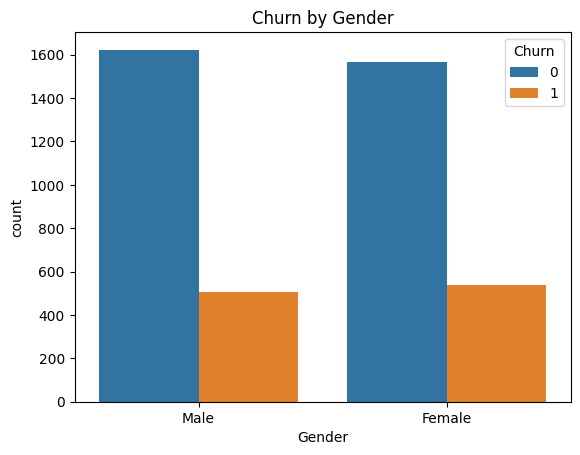

In [58]:
sns.countplot(x='Gender', hue='Churn', data=train_merged)
plt.title("Churn by Gender")
plt.show()

Gender is not a strong factor in predicting churn

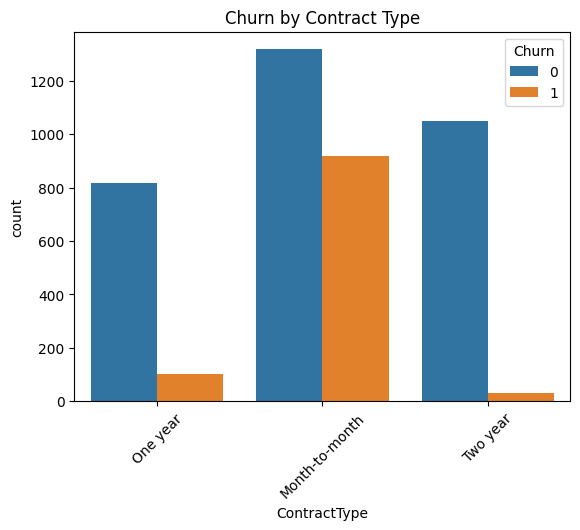

In [59]:
sns.countplot(x='ContractType', hue='Churn', data=train_merged)
plt.xticks(rotation=45)
plt.title("Churn by Contract Type")
plt.show()

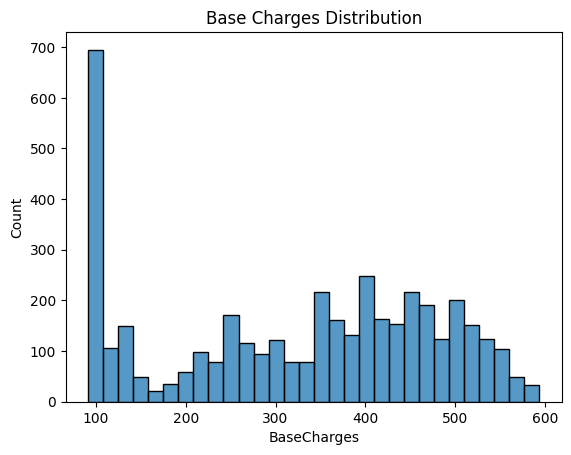

In [62]:
sns.histplot(train_merged['BaseCharges'], bins=30)

plt.title("Base Charges Distribution")
plt.show()

# Month-to-Month contracts are far more likely to churn

Dealing with missing values

In [61]:
# Identify columns with missing values we want to drop rows for
cols_to_check_for_na = ['TotalCharges', 'ContractType', 'Education', 'Gender'] + list(pivoted_services.columns[1:]) # Also include new service columns

train_merged.dropna(subset=cols_to_check_for_na, inplace=True)

test_merged.dropna(subset=cols_to_check_for_na, inplace=True)


In [65]:
# Convert DOC and DOE to datetime objects
train_merged['DOC'] = pd.to_datetime(train_merged['DOC'], format='%d-%m-%Y', errors='coerce')
train_merged['DOE'] = pd.to_datetime(train_merged['DOE'], format='%d-%b-%y', errors='coerce') # Assuming format like '10-Jan-11'

test_merged['DOC'] = pd.to_datetime(test_merged['DOC'], format='%d-%m-%Y', errors='coerce')
test_merged['DOE'] = pd.to_datetime(test_merged['DOE'], format='%d-%b-%y', errors='coerce')

# Create a 'tenure' feature (e.g., in months or days)
# Let's assume tenure is the duration of the contract from DOE to DOC.
# Or, more commonly, from DOE to a 'current' date (which isn't given, so we use DOC as proxy for observation point).
# If DOC is the start of current contract and DOE is start of customer relationship, let's use a proxy for service duration.
# A common practice is to calculate tenure based on 'TotalCharges' (if it represents accumulated charges over time)
# or, if 'TotalCharges' is accumulated, and 'BaseCharges' is monthly, then Tenure = TotalCharges / BaseCharges.
# Let's create 'tenure' from 'TotalCharges' / 'BaseCharges' if 'BaseCharges' > 0, otherwise 0.

train_merged['Tenure_Calc'] = train_merged.apply(
    lambda row: row['TotalCharges'] / row['BaseCharges'] if row['BaseCharges'] > 0 else 0,
    axis=1
)
test_merged['Tenure_Calc'] = test_merged.apply(
    lambda row: row['TotalCharges'] / row['BaseCharges'] if row['BaseCharges'] > 0 else 0,
    axis=1
)

# Also create a 'ServiceDurationDays' from DOE to DOC
train_merged['ServiceDurationDays'] = (train_merged['DOC'] - train_merged['DOE']).dt.days
test_merged['ServiceDurationDays'] = (test_merged['DOC'] - test_merged['DOE']).dt.days

# Convert 'Retired', 'HasPartner', 'HasDependents' to binary (0/1)
# Based on info(), 2 seems to mean 'Yes', 0 means 'No'. HasPartner and HasDependents could be binary.
# Let's map 2 to 1 for consistency with boolean True.
for col in ['Retired', 'HasPartner', 'HasDependents']:
    train_merged[col] = train_merged[col].replace(2, 1)
    test_merged[col] = test_merged[col].replace(2, 1)

print("Train_merged after feature engineering head:")
display(train_merged.head())
print("Train_merged info after feature engineering:")
train_merged.info()

Train_merged after feature engineering head:


,CustomerNo,Churn,BaseCharges,DOC,TotalCharges,DOE,ElectronicBilling,ContractType,PaymentMethod,Country,...,HasPhoneService,InternetServiceCategory,MultipleLines,OnlineBackup,OnlineSecurity,StreamingMovies,StreamingTelevision,TechnicalSupport,Tenure_Calc,ServiceDurationDays
0,1201,0,478.50,2012-01-05,5920.00,2011-01-10,No,One year,Electronic check,India,...,Yes,Fiber optic,No,No,No,Yes,Yes,No,12.371996,360
1,1202,0,103.25,2012-01-05,103.25,2011-12-06,No,Month-to-month,Electronic check,India,...,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,1.000000,30
2,1205,1,372.50,2012-01-05,372.50,2011-12-06,Yes,Month-to-month,Electronic check,India,...,Yes,Fiber optic,Yes,No,No,No,No,No,1.000000,30
3,1206,0,99.50,2012-01-05,6775.50,2006-03-07,Yes,Two year,Credit card (automatic),India,...,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,68.095477,2130
4,1207,0,91.25,2012-01-05,2673.50,2009-09-17,No,One year,Credit card (automatic),India,...,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,29.298630,840


Train_merged info after feature engineering:
<class 'pandas.core.frame.DataFrame'>
Index: 4216 entries, 0 to 4237
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   CustomerNo               4216 non-null   int64         
 1   Churn                    4216 non-null   int64         
 2   BaseCharges              4216 non-null   float64       
 3   DOC                      4216 non-null   datetime64[ns]
 4   TotalCharges             4216 non-null   float64       
 5   DOE                      4216 non-null   datetime64[ns]
 6   ElectronicBilling        4216 non-null   object        
 7   ContractType             4216 non-null   object        
 8   PaymentMethod            4216 non-null   object        
 9   Country                  4216 non-null   object        
 10  State                    4216 non-null   object        
 11  Retired                  4216 non-null   int64         

### Step 4: Categorical Encoding

In [71]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Identify categorical columns for encoding
categorical_features = train_merged.select_dtypes(include='object').columns.tolist()
# Remove 'DOC' and 'DOE' if they are still object type and not needed directly
categorical_features = [col for col in categorical_features if col not in ['DOC', 'DOE']]

print("Categorical features to encode:", categorical_features)

# Apply One-Hot Encoding to categorical features
train_encoded_df = pd.get_dummies(train_merged, columns=categorical_features, drop_first=True)
test_encoded_df = pd.get_dummies(test_merged, columns=categorical_features, drop_first=True)

# Store labels and IDs before dropping from feature sets
train_labels = train_encoded_df['Churn']
train_ids = train_encoded_df['CustomerNo']
test_ids = test_encoded_df['CustomerNo']

# Drop original ID, Churn, and raw date columns from feature DataFrames
columns_to_drop = ['CustomerNo', 'Churn', 'DOC', 'DOE']
train_final = train_encoded_df.drop(columns=columns_to_drop, errors='ignore')
test_final = test_encoded_df.drop(columns=[col for col in columns_to_drop if col != 'Churn'], errors='ignore') # 'Churn' is not in test_merged

# Align columns - crucial for consistent feature sets between train and test
# This ensures test_final has the exact same columns as train_final
missing_in_test = set(train_final.columns) - set(test_final.columns)
for c in missing_in_test:
    test_final[c] = 0

# Drop columns from train_final that are not in test_final (if any, though less likely)
missing_in_train = set(test_final.columns) - set(train_final.columns)
for c in missing_in_train:
    train_final[c] = 0

# Ensure the order of columns is the same
test_final = test_final[train_final.columns]

print("\nTrain_final shape after encoding:", train_final.shape)
print("Test_final shape after encoding:", test_final.shape)
print("Train_final head:")
display(train_final.head())

Categorical features to encode: ['ElectronicBilling', 'ContractType', 'PaymentMethod', 'Country', 'State', 'Education', 'Gender', 'DeviceProtection', 'HasPhoneService', 'InternetServiceCategory', 'MultipleLines', 'OnlineBackup', 'OnlineSecurity', 'StreamingMovies', 'StreamingTelevision', 'TechnicalSupport']

Train_final shape after encoding: (4216, 37)
Test_final shape after encoding: (1053, 37)
Train_final head:


,BaseCharges,TotalCharges,Retired,HasPartner,HasDependents,Tenure_Calc,ServiceDurationDays,ElectronicBilling_Yes,ContractType_One year,ContractType_Two year,...,OnlineBackup_No internet service,OnlineBackup_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,StreamingTelevision_No internet service,StreamingTelevision_Yes,TechnicalSupport_No internet service,TechnicalSupport_Yes
0,478.50,5920.00,0,1,1,12.371996,360,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,103.25,103.25,0,1,1,1.000000,30,False,False,False,...,True,False,True,False,True,False,True,False,True,False
2,372.50,372.50,0,1,1,1.000000,30,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,99.50,6775.50,0,1,1,68.095477,2130,True,False,True,...,True,False,True,False,True,False,True,False,True,False
4,91.25,2673.50,0,1,1,29.298630,840,False,True,False,...,True,False,True,False,True,False,True,False,True,False


In [72]:
from sklearn.ensemble import RandomForestClassifier

# Define X_train and y_train
X_train = train_final.copy()
y_train = train_labels.copy()

# Initialize the Random Forest Classifier
# Using a random_state for reproducibility
# n_estimators can be tuned, starting with 100
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available cores

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest Classifier trained successfully!")

Random Forest Classifier trained successfully!


In [74]:
# Make predictions on the preprocessed test data using the Random Forest model
y_test_pred_rf = rf_model.predict(test_final)

# Create the initial submission DataFrame from the processed test set
submission_df_rf = pd.DataFrame({'CustomerNo': test_ids, 'Churn': y_test_pred_rf})

# Identify CustomerNos from the original churn_test that are missing in the processed test_final
original_test_customer_nos = churn_test['CustomerNo'].unique()
processed_test_customer_nos = test_ids.unique()

missing_customer_nos = pd.Series(list(set(original_test_customer_nos) - set(processed_test_customer_nos)))

# Create a DataFrame for the missing CustomerNos, assuming a default prediction (e.g., 0 for no churn)
# This assumption might need adjustment based on business knowledge, but 0 is a safe default.
missing_submission_df = pd.DataFrame({
    'CustomerNo': missing_customer_nos,
    'Churn': 0  # Default to no churn for missing customers
})

# Concatenate the two DataFrames and ensure the CustomerNo column is unique and sorted
final_submission_df_rf = pd.concat([submission_df_rf, missing_submission_df], ignore_index=True)
final_submission_df_rf = final_submission_df_rf.sort_values(by='CustomerNo').reset_index(drop=True)

# Save the submission file to a CSV
submission_path_rf = '/content/drive/My Drive/submission_random_forest_corrected.csv'
final_submission_df_rf.to_csv(submission_path_rf, index=False)


Final submission DataFrame has 1060 rows, as required.
Submission file head (Random Forest - corrected):


,CustomerNo,Churn
0,1203,0
1,1204,0
2,1208,0
3,1220,0
4,1221,0


Submission file saved to /content/drive/My Drive/submission_random_forest_corrected.csv
You can now download this file and submit it to Kaggle. Good luck!


In [76]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
# Using a random_state for reproducibility
lr_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets and L1/L2 regularization

# Train the model
lr_model.fit(X_train, y_train)


LogisticRegression(random_state=42, solver='liblinear')

In [79]:
# Make predictions on the preprocessed test data
y_test_pred_lr = lr_model.predict(test_final)

# Create the initial submission DataFrame
submission_df_lr = pd.DataFrame({'CustomerNo': test_ids, 'Churn': y_test_pred_lr})

# Identify CustomerNos from the original churn_test that are missing in the processed test_final
original_test_customer_nos = churn_test['CustomerNo'].unique()
processed_test_customer_nos = test_ids.unique()

missing_customer_nos = pd.Series(list(set(original_test_customer_nos) - set(processed_test_customer_nos)))

# Create a DataFrame for the missing CustomerNos, assuming a default prediction (e.g., 0 for no churn)
missing_submission_df = pd.DataFrame({
    'CustomerNo': missing_customer_nos,
    'Churn': 0  # Default to no churn for missing customers
})

# Concatenate the two DataFrames and ensure the CustomerNo column is unique and sorted
final_submission_df_lr = pd.concat([submission_df_lr, missing_submission_df], ignore_index=True)
final_submission_df_lr = final_submission_df_lr.sort_values(by='CustomerNo').reset_index(drop=True)

# Save the submission file to a CSV
submission_path_lr = '/content/drive/My Drive/submission_lr_model_corrected.csv'
final_submission_df_lr.to_csv(submission_path_lr, index=False)

In [81]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [82]:
# Make predictions on the preprocessed test data using the Decision Tree model
y_test_pred_dt = dt_model.predict(test_final)

# Create the initial submission DataFrame from the processed test set
submission_df_dt = pd.DataFrame({'CustomerNo': test_ids, 'Churn': y_test_pred_dt})

# Identify CustomerNos from the original churn_test that are missing in the processed test_final
original_test_customer_nos = churn_test['CustomerNo'].unique()
processed_test_customer_nos = test_ids.unique()

missing_customer_nos = pd.Series(list(set(original_test_customer_nos) - set(processed_test_customer_nos)))

# Create a DataFrame for the missing CustomerNos, assuming a default prediction (e.g., 0 for no churn)
missing_submission_df = pd.DataFrame({
    'CustomerNo': missing_customer_nos,
    'Churn': 0  # Default to no churn for missing customers
})

# Concatenate the two DataFrames and ensure the CustomerNo column is unique and sorted
final_submission_df_dt = pd.concat([submission_df_dt, missing_submission_df], ignore_index=True)
final_submission_df_dt = final_submission_df_dt.sort_values(by='CustomerNo').reset_index(drop=True)

# Save the submission file to a CSV
submission_path_dt = '/content/drive/My Drive/submission_decision_tree_corrected.csv'
final_submission_df_dt.to_csv(submission_path_dt, index=False)